# Global Equity Risk: Covariance Forecasting and Model Validation

*An independent validation extension of my MSc research.*

**Question.** Does dynamic correlation improve weekly risk forecasts enough to justify its complexity?

**Finding.** Across two rolling evaluation periods, DCC does not establish a clear incremental advantage over CCC under the specified losses. Ignoring cross-market covariance produces substantially excessive Gaussian VaR exceptions for the equal-weight research composite. Correct average coverage alone does not establish adequate tail modelling.

This is a model-validation study, not a trading strategy. The universe contains eight markets selected retrospectively for complete weekly coverage. The 2020–2025 period was previously examined in the original research and is **not an untouched holdout**.

**閱讀方式：** 主文依序看資料設定、模型比較、估計診斷、VaR 與敏感度。程式可逐格執行；預設讀取已驗證結果，完整重算方式見 `README.md`。細表與原理檢查另見 `Diagnostics_Appendix.ipynb`。


## 1. Reproducible setup

The bundled snapshot is frozen. Cached results are accepted only when data, model code, configuration and result-file hashes match the manifest. The manifest records the estimation environment; the appendix displays both recorded and current versions.

Shared estimation functions are in **[risk_model.py](risk_model.py)**. They implement the equations below; the notebook concentrates on the validation decisions and evidence.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import risk_model as rm

# Open Jupyter in this project folder. No user-specific paths are required.
PROJECT_ROOT = Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "global_index_prices_2005_2025.csv"
assert DATA_PATH.exists(), "Open this notebook from the project folder; see README.md."
RECOMPUTE = False  # True: re-estimate all models; False: verify and read saved results.

if RECOMPUTE:
    run_dir = rm.recompute(DATA_PATH, PROJECT_ROOT / "results")
    (PROJECT_ROOT / "results" / "SELECTED_RUN.txt").write_text(run_dir.name + "\n")
else:
    selected = (PROJECT_ROOT / "results" / "SELECTED_RUN.txt").read_text().strip()
    run_dir = PROJECT_ROOT / "results" / selected

bundle = rm.load_run(run_dir, DATA_PATH)
scores = bundle["scores"]
prices, weekly_prices, source_dates, returns, schedule = rm.prepare_data(DATA_PATH)
pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 4)
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
print("Verified run:", run_dir.name)
print("Return unit: percentage log return; markets:", len(rm.RESEARCH_MARKETS))


Verified run: run_20260914_190025_161649
Return unit: percentage log return; markets: 8


## 2. Data and forecast design

Daily prices are aggregated to the last available observation in each Friday-labelled week. Missing weeks are retained before calculating returns; no forward filling is used. Only markets with complete weekly coverage in this snapshot enter the fixed research universe.

Each forecast uses the previous **260 weeks**, excluding the target observation. Parameters are re-estimated weekly. Evaluation periods are 2015–2019 and 2020–2025.

**Scope and limitations**

- The weighted combination of local-currency log returns is a **research composite**, not the exact return of a tradable common-currency portfolio.
- Calendar-date endpoints can differ; even matching dates have different closing times. This is a weekly proxy, not a synchronised tradable execution schedule.
- The snapshot does not retain a verified acquisition manifest. `source_inventory.csv` lists original downloader settings separately from unverified actual tickers and price types. The original code preferred adjusted close and otherwise close; this does not prove consistent total-return treatment.
- Frozen vendor prices and full-sample universe selection are not point-in-time constituent or data-vintage reconstruction.

The intended local-currency index interpretation remains conditional on source verification. Original backup tickers may change the exposure or currency; configuration labels alone cannot settle this.


In [2]:
design = schedule.groupby("Evaluation_period", sort=False).agg(
    First_target=("Target_week", "min"), Last_target=("Target_week", "max"),
    Forecasts=("Target_week", "size"), Endpoint_mismatch_weeks=("Endpoint_mismatch", "sum"),
)
display(design)
display(pd.DataFrame({"Market": rm.RESEARCH_MARKETS, "Weight": rm.CONFIG["weights"]}))


,First_target,Last_target,Forecasts,Endpoint_mismatch_weeks
Evaluation_period,,,,
Development,2015-01-02,2019-12-27,261,72
Later historical evaluation,2020-01-03,2025-12-26,313,86


,Market,Weight
0,US,0.125
1,UK,0.125
2,Germany,0.125
3,France,0.125
4,Hong Kong,0.125
5,India,0.125
6,Brazil,0.125
7,South Africa,0.125


## 3. Models and scores

All primary models use a zero conditional mean. The original development comparison found no mean-MSE improvement from VAR(1); this does not resolve residual whiteness or prove expected returns are zero. A refitted historical-mean CCC sensitivity is reported below.

| Model | Marginal risk | Cross-market dependence |
|---|---|---|
| Diagonal GARCH | Student-t GARCH(1,1) | Covariances set to zero; diagnostic ablation |
| CCC-GARCH | Same GARCH forecasts | Training-window correlation of standardised residuals |
| DCC-GARCH | Same GARCH forecasts | DCC(1,1), Gaussian second-stage quasi-likelihood |
| EWMA | Normalised exponential weighting of return outer products | Estimated jointly with variances; 13-week half-life |

DCC uses $Q_t=(1-a-b)\bar Q+a z_{t-1}z_{t-1}'+bQ_{t-1}$, normalised to $R_t$, and $H_t=D_tR_tD_t$. The training-window target is the centred sample covariance of standardised residuals (`ddof=1`). Four SLSQP starts are compared with $a,b\geq0$, $a+b\leq0.999$. The final update uses the last training residual. These choices match the reviewed implementation; they do not guarantee a global optimum. [Engle (2002)](https://doi.org/10.1198/073500102288618487), [arch documentation](https://arch.readthedocs.io/en/stable/univariate/univariate_volatility_modeling.html).

EWMA weights decay by one half every 13 weeks and are normalised over the same 260 observations. The half-life is a fixed research setting, not an optimised parameter. [RiskMetrics technical document](https://www.msci.com/documents/10199/5915b101-4206-4ba0-aee2-3449d5c7e95a).

For error vector $e_t$, composite error $e_{p,t}=w'e_t$, and variance forecast $h_t=w'H_tw$, lower scores are better:

- Portfolio QLIKE form: $\log h_t+e_{p,t}^2/h_t$.
- Multivariate Gaussian score: $\log|H_t|+e_t'H_t^{-1}e_t$, omitting common constants and a factor of $1/2$.
- Variance MSE: $(e_{p,t}^2-h_t)^2$.

The first two are related scalar and multivariate Gaussian scoring forms, not independent evidence. Squared returns are noisy variance proxies; QLIKE is not immune to extreme observations. Differences across models are compared within a metric and period, not across score scales.


## 4. Forecast comparison

The means below describe performance. Approximate HAC intervals assess paired weekly differences. Lag 4 is the primary bandwidth; DCC–CCC lags 8 and 13 are retained in the appendix. Intervals and p-values are not adjusted for multiple comparisons or all model-development choices. [Newey–West](https://www.nber.org/papers/t0055), [statsmodels HAC implementation](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_robustcov_results.html).


In [3]:
loss_summary = scores.groupby(["Evaluation_period", "Model"])[rm.LOSS_COLUMNS].mean()
display(loss_summary.round(5))
hac = rm.hac_comparisons(scores)
for period, group in hac.loc[hac.Lag.eq(4)].groupby("Period", sort=False):
    display(Markdown(f"**{period} — negative differences favour the first model**"))
    display(group.set_index(["Comparison", "Metric"])[["Mean_difference", "CI_lower", "CI_upper", "p_value"]].round(5))


Portfolio_QLIKE  \
Evaluation_period           Model                                       
Development                 CCC-GARCH                          1.9785   
                            DCC-GARCH                          1.9796   
                            Diagonal GARCH                     3.7311   
                            EWMA (13-week half-life)           1.9952   
Later historical evaluation CCC-GARCH                          2.4437   
                            DCC-GARCH                          2.4386   
                            Diagonal GARCH                     5.0048   
                            EWMA (13-week half-life)           2.4989   

                                                      Multivariate_Gaussian_loss  \
Evaluation_period           Model                                                  
Development                 CCC-GARCH                                    14.9670   
                            DCC-GARCH                                    14.9354   
                            Diagonal GARCH                               19.9658   
                            EWMA (13-week half-life)                     15.7376   
Later historical evaluation CCC-GARCH                                    17.6707   
                            DCC-GARCH                                    17.6802   
                            Diagonal GARCH                               23.3708   
                            EWMA (13-week half-life)                     19.8233   

                                                      Portfolio_variance_MSE  
Evaluation_period           Model                                             
Development                 CCC-GARCH                                23.8793  
                            DCC-GARCH                                23.9086  
                            Diagonal GARCH                           29.1414  
                            EWMA (13-week half-life)                 24.1969  
Later historical evaluation CCC-GARCH                               270.9142  
                            DCC-GARCH                               269.9487  
                            Diagonal GARCH                          301.8751  
                            EWMA (13-week half-life)                282.0851

<IPython.core.display.Markdown object>

,,Mean_difference,CI_lower,CI_upper,p_value
Comparison,Metric,,,,
DCC − CCC,Portfolio_QLIKE,0.0011,-0.0010,0.0032,0.3160
CCC − EWMA,Portfolio_QLIKE,-0.0167,-0.0756,0.0421,0.5775
DCC − CCC,Multivariate_Gaussian_loss,-0.0316,-0.0694,0.0062,0.1013
CCC − EWMA,Multivariate_Gaussian_loss,-0.7706,-1.2347,-0.3066,0.0011
DCC − CCC,Portfolio_variance_MSE,0.0293,-0.0193,0.0779,0.2380
CCC − EWMA,Portfolio_variance_MSE,-0.3176,-1.0681,0.4329,0.4069


<IPython.core.display.Markdown object>

,,Mean_difference,CI_lower,CI_upper,p_value
Comparison,Metric,,,,
DCC − CCC,Portfolio_QLIKE,-0.0052,-0.0149,0.0046,0.2987
CCC − EWMA,Portfolio_QLIKE,-0.0552,-0.1329,0.0226,0.1644
DCC − CCC,Multivariate_Gaussian_loss,0.0095,-0.0669,0.0859,0.8076
CCC − EWMA,Multivariate_Gaussian_loss,-2.1525,-4.2234,-0.0817,0.0416
DCC − CCC,Portfolio_variance_MSE,-0.9655,-2.7710,0.8399,0.2946
CCC − EWMA,Portfolio_variance_MSE,-11.1710,-22.6868,0.3449,0.0573


**Decision.** DCC–CCC 95% HAC intervals contain zero for all three metrics in both periods. This does not establish equivalence. CCC–EWMA multivariate Gaussian losses favour CCC, with unadjusted p-values around 0.0011 in development and 0.0416 later; portfolio-loss evidence is weaker. CCC remains the simpler reference model, not a proven universal winner.


## 5. Numerical reliability

Check the entire rolling evaluation rather than only the first fitted window. A valid DCC solution is the lowest-objective **valid attempted** solution. The disagreement flag uses an objective range above (10^{-6}); this is a numerical diagnostic, not a significance test.


In [4]:
stability = rm.stability_summary(bundle)
display(stability.round(6))
print("Recorded estimation warnings:", len(bundle["warnings"]))


Recorded estimation warnings: 0


,Windows,Marginal_fits,GARCH_persistence_ge_0999,DCC_start_disagreement,Selected_best_attempt,Min_covariance_eigenvalue
Period,,,,,,
Development,261,2088,14,55,True,0.1517
Later historical evaluation,313,2504,19,269,True,0.1966


**Limits.** Development has 55/261 windows with multiple-start disagreement; the later period has 269/313. All selected the best valid attempted objective. Near-boundary GARCH estimates (`alpha + beta >= 0.999`) occur in 14/2,088 and 19/2,504 primary marginal fits respectively. Finite positive one-step forecasts do not establish strict stationarity or reliable long-run mean reversion. Boundary dates are retained. Solver status, marginal parameters, start details and warnings are saved for review.


## 6. Tail-risk validation

All models receive the same additional **Gaussian tail assumption**: lower return threshold $q_\alpha=\Phi^{-1}(\alpha)\sqrt{w'H_tw}$. An exception is a realised composite return below this threshold. Student-t marginal fits do not establish a Student-t law for the composite.

Exact binomial inference assumes independent Bernoulli hits with a fixed probability. First-order independence diagnostics are shown in the appendix; sparse transitions limit interpretation. Tests that do not reject are not model-acceptance certificates. [SciPy binomial test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html), [Christoffersen (1998)](https://users.ssc.wisc.edu/~bhansen/718/Christoffersen1998.pdf).


In [5]:
var_details, coverage, independence = rm.var_analysis(scores)
display(coverage.set_index(["Model", "Confidence_pct"])[
    ["Exceptions", "Expected", "Rate_pct", "Rate_CI_lower_pct", "Rate_CI_upper_pct", "Coverage_p", "Max_exceedance_pp"]
].round(4))


Exceptions  Expected  Rate_pct  \
Model                    Confidence_pct                                   
CCC-GARCH                95                      14     15.65    4.4728   
                         99                       6      3.13    1.9169   
DCC-GARCH                95                      14     15.65    4.4728   
                         99                       6      3.13    1.9169   
Diagonal GARCH           95                      53     15.65   16.9329   
                         99                      35      3.13   11.1821   
EWMA (13-week half-life) 95                      16     15.65    5.1118   
                         99                       6      3.13    1.9169   

                                         Rate_CI_lower_pct  Rate_CI_upper_pct  \
Model                    Confidence_pct                                         
CCC-GARCH                95                         2.4666             7.3909   
                         99                         0.7067             4.1255   
DCC-GARCH                95                         2.4666             7.3909   
                         99                         0.7067             4.1255   
Diagonal GARCH           95                        12.9487            21.5562   
                         99                         7.9135            15.2074   
EWMA (13-week half-life) 95                         2.9497             8.1687   
                         99                         0.7067             4.1255   

                                         Coverage_p  Max_exceedance_pp  
Model                    Confidence_pct                                 
CCC-GARCH                95                  0.7951            11.1120  
                         99                  0.1396             9.2769  
DCC-GARCH                95                  0.7951            11.0399  
                         99                  0.1396             9.1750  
Diagonal GARCH           95                  0.0000            13.5188  
                         99                  0.0000            12.6809  
EWMA (13-week half-life) 95                  0.8965            11.0781  
                         99                  0.1396             9.2290

**Interpretation.** Diagonal GARCH produces far too many exceptions. CCC and DCC have identical exception dates: 14 at 95% and six at 99%. For six exceptions in 313 weeks, the 95% interval for the hit probability is approximately 0.71%–4.13%; nominal 1% coverage is not rejected, but uncertainty is substantial. Large losses still exceed thresholds by several percentage points. Fewer exceptions alone are not necessarily better: wider thresholds may simply be more conservative.

The following year was selected **retrospectively for illustration**, not as a prespecified stress sample. All weeks in 2020 remain visible.


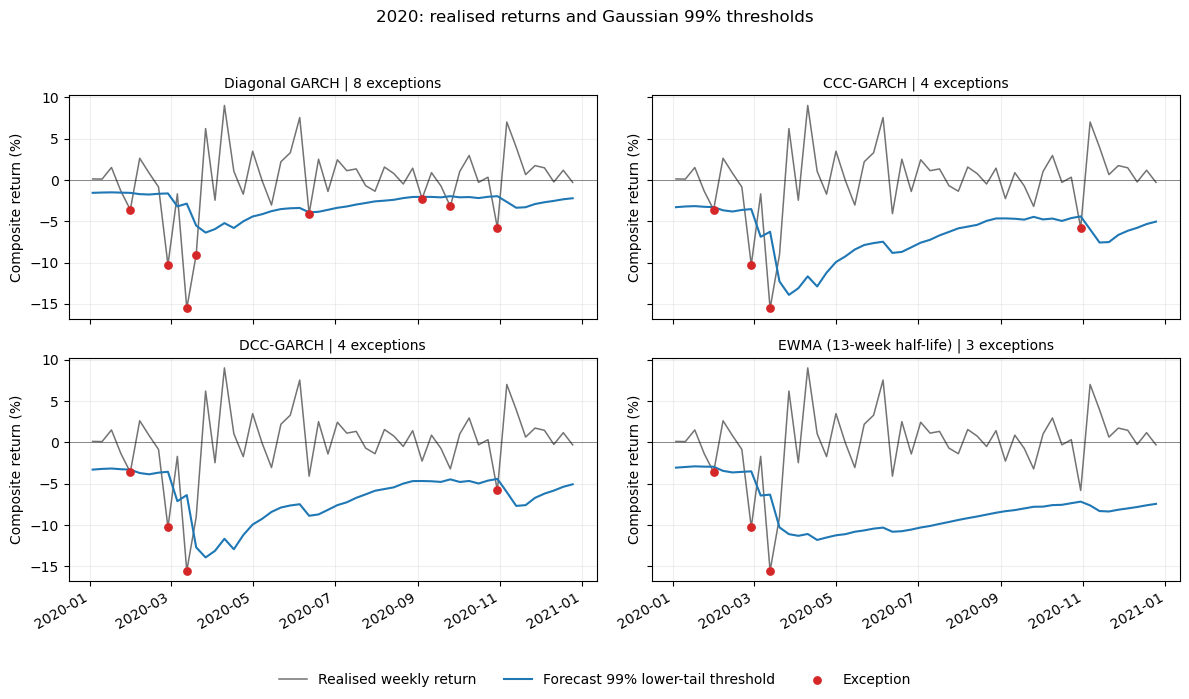

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
plot_data = var_details.loc[var_details.Confidence_pct.eq(99) & var_details.Target_week.dt.year.eq(2020)]
for ax, model in zip(axes.flat, rm.MODEL_ORDER):
    g = plot_data.loc[plot_data.Model.eq(model)].sort_values("Target_week")
    hit = g.loc[g.Exception]
    ax.plot(g.Target_week, g.Composite_return_pct, color="0.45", lw=1.1, label="Realised weekly return")
    ax.plot(g.Target_week, g.Return_threshold_pct, color="tab:blue", lw=1.5, label="Forecast 99% lower-tail threshold")
    ax.scatter(hit.Target_week, hit.Composite_return_pct, color="tab:red", s=28, zorder=3, label="Exception")
    ax.axhline(0, color="black", lw=.6, alpha=.5)
    ax.set_title(f"{model} | {len(hit)} exceptions", fontsize=10)
    ax.set_ylabel("Composite return (%)")
    ax.grid(alpha=.2)
fig.suptitle("2020: realised returns and Gaussian 99% thresholds")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.autofmt_xdate(rotation=30)
fig.tight_layout(rect=[0, .07, 1, .95])
fig.savefig(FIGURE_DIR / "gaussian_var_2020.png", dpi=180, bbox_inches="tight")
plt.show()


CCC and DCC thresholds nearly overlap. EWMA remains more negative for longer after the March moves. Threshold adjustment after large returns is evidence of updating, not evidence that those events were predicted beforehand. The figure cannot isolate covariance errors from an inadequate Gaussian tail assumption.


## 7. Sensitivity checks

**Endpoint timing.** Existing forecasts are grouped by whether all markets' starting and ending calendar dates match. This does not refit models on synchronised training data or identify a causal effect of timing.

**Conditional mean.** CCC is refitted after subtracting each training window's historical market means. The mean is estimated separately from GARCH and then included in the forecast error. Both periods are reported as a post-development check. Variance MSE changes its squared-error target when the mean changes; use it cautiously for joint mean–covariance ranking. This does not test every model under VAR means.


In [7]:
timing = rm.timing_comparisons(scores)
display(timing.pivot(index=["Comparison", "Metric"], columns="Endpoint_mismatch", values="Mean_difference")
        .rename(columns={False: "Aligned endpoints (227)", True: "Mismatched endpoints (86)"}).round(5))
means = bundle["mean_sensitivity"].groupby(["Evaluation_period", "Mean_specification"])[rm.LOSS_COLUMNS].mean()
display(Markdown("**Historical mean minus zero mean: negative favours historical mean**"))
display((means.xs("Historical mean", level="Mean_specification") - means.xs("Zero mean", level="Mean_specification")).round(5))


Endpoint_mismatch                      Aligned endpoints (227)  \
Comparison Metric                                                
CCC − EWMA Multivariate_Gaussian_loss                  -2.2343   
           Portfolio_QLIKE                             -0.0321   
           Portfolio_variance_MSE                      -9.8402   
DCC − CCC  Multivariate_Gaussian_loss                   0.0033   
           Portfolio_QLIKE                             -0.0062   
           Portfolio_variance_MSE                      -1.3442   

Endpoint_mismatch                      Mismatched endpoints (86)  
Comparison Metric                                                 
CCC − EWMA Multivariate_Gaussian_loss                    -1.9368  
           Portfolio_QLIKE                               -0.1161  
           Portfolio_variance_MSE                       -14.6835  
DCC − CCC  Multivariate_Gaussian_loss                     0.0259  
           Portfolio_QLIKE                               -0.0024  
           Portfolio_variance_MSE                         0.0339

<IPython.core.display.Markdown object>

,Portfolio_QLIKE,Multivariate_Gaussian_loss,Portfolio_variance_MSE
Evaluation_period,,,
Development,-0.0065,0.0339,0.8540
Later historical evaluation,-0.0020,-0.0176,5.6876


CCC has lower mean losses than EWMA in both timing groups. DCC–CCC comparison directions are unchanged except variance MSE. Subgroup differences have not been assigned significance claims, and same-date prices still close at different times.

Historical means produce mixed score changes. The zero-mean primary specification is retained for parsimony, not because superiority or zero expected returns has been established.


## 8. Conclusion and limits

The evidence supports **retaining CCC as the simpler reference** and treating DCC as a challenger whose incremental value remains unestablished in this design. Cross-market covariance matters for the research composite: removing it yields markedly excessive Gaussian VaR exceptions.

Five large-move weeks account for roughly 84%–88% of later-period variance MSE. Tail severity therefore remains important even when coverage tests do not reject. These findings concern the fixed universe, local-currency composite, weekly proxy calendar, model settings and historical sample—not production readiness or a trading return.

Before stronger claims: verify snapshot provenance and consistent index return types; independently examine difficult optimisation windows; evaluate alternative predictive tail specifications on an appropriately designed future sample. These are limitations and possible extensions, not completed validations.

**Supporting materials:** [diagnostic appendix](Diagnostics_Appendix.ipynb), [method implementation](risk_model.py), [run instructions](README.md), and the run manifest under `results/`.
